# Responsible AI Lab 4 - Saliency Maps
This week we'll look at explaining image classification with saliency maps. We'll use the [PAIR Saliency Library](https://github.com/PAIR-code/saliency) to look at how to load in different models and images (including perturbing images), which will be useful for the coursework. You will need to add the images uploaded in moodle to your colab files (the little folder icon on in the menu bar on the left).

This exercise is a modified version of the PAIR [example notebook](https://github.com/PAIR-code/saliency/blob/master/Examples_core.ipynb) - we will only look at the Gradient and SmoothGrad methods in this lab, but if you are interested in other methods please see the PAIR [example notebook](https://github.com/PAIR-code/saliency/blob/master/Examples_core.ipynb).

We use Tensorflow(2) in this notebook, however if you are more comfortable with PyTorch, PAIR also have an [example notebook using PyTorch here](https://github.com/PAIR-code/saliency/blob/master/Examples_pytorch.ipynb). You can also find a list of PyTorch pre-trained models [here](https://pytorch.org/vision/stable/models.html).




## What are Saliency Maps

They are a tool used to enhance the interpretability of Computer Vision ML models. In particular, they can help us understand what the convolutional layers in these models ***see*** and base their decisions on.

## Install and import libraries


In [1]:
# Install PAIR Saliency Library
!pip install saliency


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 3.0 MB/s eta 0:00:00


In [9]:
# Boilerplate imports.
import tensorflow as tf
import numpy as np
import PIL.Image
from matplotlib import pylab as P
import requests

# From PAIR saliency repository.
import saliency.core as saliency

%matplotlib inline

## Utility methods
**Note:** If you were to try using a differenet model, you would need to modify the "PreprocessImage" method, as different models require different pre-processing.

In [10]:
# Boilerplate methods.
def ShowImage(im, title='', ax=None):
  if ax is None:
    P.figure()
  P.axis('off')
  P.imshow(im)
  P.title(title)

def ShowGrayscaleImage(im, title='', ax=None):
  if ax is None:
    P.figure()
  P.axis('off')

  P.imshow(im, cmap=P.cm.gray, vmin=0, vmax=1)
  P.title(title)

def ShowHeatMap(im, title, ax=None):
  if ax is None:
    P.figure()
  P.axis('off')
  P.imshow(im, cmap='inferno')
  P.title(title)

def LoadImage(url_or_filepath):
       if url_or_filepath.startswith('http'): # If it's a URL
           response = requests.get(url_or_filepath, stream=True)
           response.raise_for_status()  # Raise an exception for bad responses
           im = PIL.Image.open(response.raw)
       else: # If it's a local file path
           im = PIL.Image.open(url_or_filepath)
       im = im.resize((224, 224))
       im = np.asarray(im)
       return im

def PreprocessImage(im):
  im = tf.keras.applications.vgg16.preprocess_input(im)
  return im

## Loading in a model

In this case we are loading in the (pre-trained) VGG16 model for the [ImageNet](https://www.image-net.org/about.php) dataset (ImageNet is a dataset of ~14Million images, with 1,000 classes - it is one of the most popular benchmarking datasets for image classification).

Tensorflow/Keras have a range of models pre-trained on ImageNet (which is very handy as training with such a large image dataset is very time consuming and compute intensive!) - a table of these models and some of there properties (accuracy, size, etc.) is [here](https://keras.io/api/applications/).

The documentation for the model we are using (including the preprocessing needed) can be found in the [Keras API](https://keras.io/api/applications/vgg/#vgg16-function) and in the [Tensorflow API](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16) (these contain basically the same information, just formatted differently, so you can look at whichever you prefer). In both you can an navigate to the info for other models via the menu on the left.

In [4]:
# Change the below line to load in a different model!
m = tf.keras.applications.vgg16.VGG16(weights='imagenet', include_top=True)
model = tf.keras.models.Model([m.inputs], [m.output])

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


call_model_function is how we pass inputs to our model and receive outputs necessary to compute saliency masks. The description of this method and necessary outputs is in the PAIR Library in the base CoreSaliency description, as well as separately for each method.

In [6]:
class_idx_str = 'class_idx_str'
def call_model_function(images, call_model_args=None, expected_keys=None):
    target_class_idx =  call_model_args[class_idx_str]  # extracts target class
    images = tf.convert_to_tensor(images)
    with tf.GradientTape() as tape:  # records operations for automatic diff.
      if expected_keys==[saliency.base.INPUT_OUTPUT_GRADIENTS]:  # SM needs all input-output gradients
          tape.watch(images)
          output_layer = model(images)
          output_layer = output_layer[:,target_class_idx]
          gradients = np.array(tape.gradient(output_layer, images))  # contribution of each pixel to output
          return {saliency.base.INPUT_OUTPUT_GRADIENTS: gradients}
      else:  # SM needs value of specific conv layer
          conv_layer, output_layer = model(images)
          gradients = np.array(tape.gradient(output_layer, conv_layer))
          return {saliency.base.CONVOLUTION_LAYER_VALUES: conv_layer,
                  saliency.base.CONVOLUTION_OUTPUT_GRADIENTS: gradients}

## Loading Image and Using Model to Predict Class

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Prediction class: 236


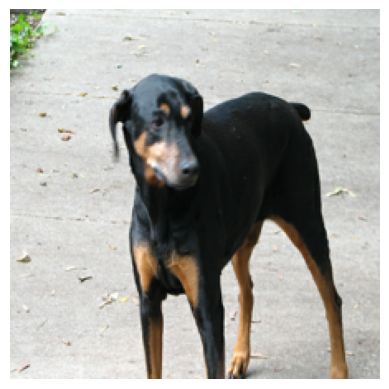

In [11]:
# Load the image
im_orig = LoadImage("https://drive.google.com/uc?export=view&id=1QVNoa3alXjpvTN0GrrCm2Tf-ZCuffCPf")
im = PreprocessImage(im_orig)  # according to VGG16 requirements

# Show the image
ShowImage(im_orig)

predictions = model([np.array([im])])
prediction_class = np.argmax(predictions[0])
call_model_args = {class_idx_str: prediction_class}

print("Prediction class: " + str(prediction_class))  # Should be a doberman, class idx = 236

## Saliency Methods - Gradient

The [gradient saliency method](https://www.semanticscholar.org/paper/Deep-Inside-Convolutional-Networks%3A-Visualising-and-Simonyan-Vedaldi/dc6ac3437f0a6e64e4404b1b9d188394f8a3bf71) (sometimes, including in the PAIR code, also called "vanilla gradient", "grad" or even just "saliency map") is one of the earliest saliency methods (from way back in 2013!). It works by taking the gradient of the class score with respect to the input. It does this for a chosen class, in the following examples (as with most examples you will see) we use the model's predicted class. For more detail on how the method works and the reasoning behind it, see section 3 of the [original paper](https://www.semanticscholar.org/reader/dc6ac3437f0a6e64e4404b1b9d188394f8a3bf71).

As we will see, the maps it produces can appear noisy, something which the methods we will look at after attempted to improve on.

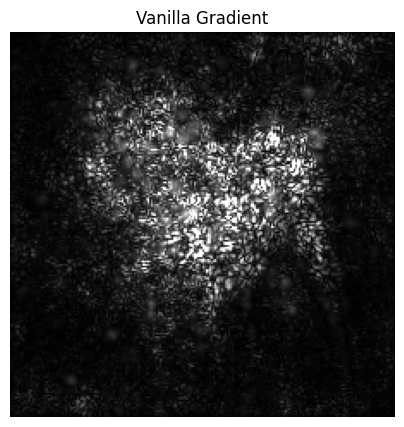

In [15]:
# Construct the saliency object. This alone doesn't do anthing.
gradient_saliency = saliency.GradientSaliency()

# Compute the vanilla mask.
vanilla_mask_3d = gradient_saliency.GetMask(im, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale = saliency.VisualizeImageGrayscale(vanilla_mask_3d)

# Set up matplot lib figures.
ROWS = 1
COLS = 1
UPSCALE_FACTOR = 5
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))

## Saliency Methods - SmoothGrad

[SmoothGrad](https://www.semanticscholar.org/paper/SmoothGrad%3A-removing-noise-by-adding-noise-Smilkov-Thorat/f538dca4def5167a32fbc12107b69a05f0c9d832) attempted to improve on the original gradient method by doing something somewhat counterintuitive - adding noise to the input! They generate several perturbed versions of the input image by adding random gaussian noise to the input image, then generate saliency maps for each of these, the final saliency map being an average across all examples. Their logic is that adding this noise and averaging smoothes the gradient, leading to less noisy and more visually coherent maps, however this has been disputed in later work - it is still not fully understood why the SmoothGrad method produces clearer looking maps!

This time we'll show the Gradient map next to the SmoothGrad map, so we can compare between them.



**Note:** SmoothGrad will take longer to run because it is taking the gradient several times (once for each perturbed example). There may also be some variation between maps each time you run it, as the noise added is generated randomly.

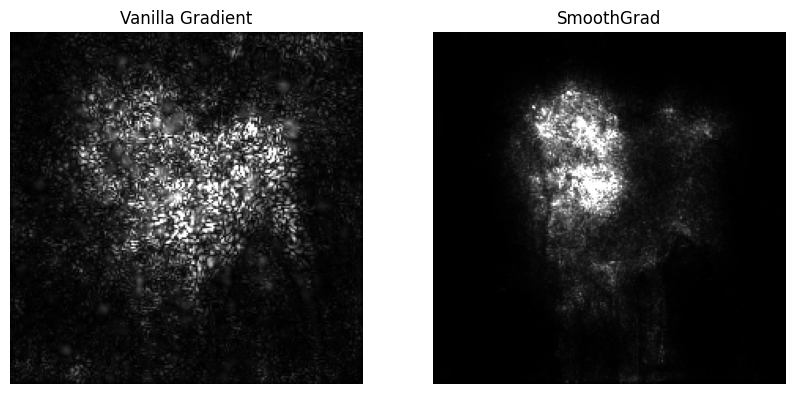

In [16]:

# Compute SmoothGrad mask.
smoothgrad_mask_3d = gradient_saliency.GetSmoothedMask(im, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
smoothgrad_mask_grayscale = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d)

# Set up matplot lib figures.
ROWS = 1
COLS = 2
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale, title='SmoothGrad', ax=P.subplot(ROWS, COLS, 2))

## Repeating with a different image

Now let's try Grad and SmoothGrad with a different image. If you want you can try loading in your own image to see what the network predicts and how the maps look, just modify the image path to contain the correct image name for your chosen image.

You can find a list of the imageNet class labels [here](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), in case you want to try running your code with a different image and want to know what class your model has predicted.

Prediction class: 207


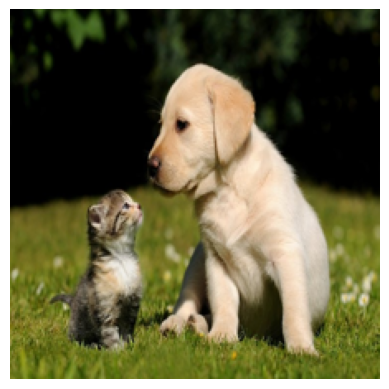

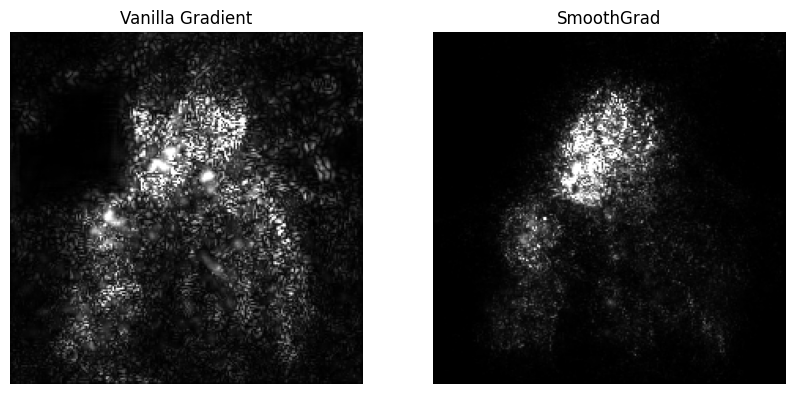

In [17]:
# Load the image
#Change the path in the line below if you want to try with a different image.
im_orig2 = LoadImage("https://drive.google.com/uc?export=view&id=1TuO4OoRutwpkwxr_T7W-imz5QvlIP20E")
im = PreprocessImage(im_orig2)

# Show the image
ShowImage(im_orig2)

predictions = model([np.array([im])])
prediction_class = np.argmax(predictions[0])
call_model_args = {class_idx_str: prediction_class}

print("Prediction class: " + str(prediction_class))  # For this image, the model predicts class 207, which is "Golden retriever"


# Compute the vanilla mask and the smoothed mask.
vanilla_mask_3d = gradient_saliency.GetMask(im, call_model_function, call_model_args)
smoothgrad_mask_3d = gradient_saliency.GetSmoothedMask(im, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale = saliency.VisualizeImageGrayscale(vanilla_mask_3d)
smoothgrad_mask_grayscale = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d)

# Set up matplot lib figures.
ROWS = 1
COLS = 2
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale, title='SmoothGrad', ax=P.subplot(ROWS, COLS, 2))


## What if we want to compare the maps from two different models?

We'll try a [ResNet50](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50) as our second model.

(If you want to see more about the different structures of the models, try calling model.summary() on each - it gives some details on the layers and parameters)

In [18]:
def PreprocessImageRes(im):
  im = tf.keras.applications.resnet50.preprocess_input(im)
  return im


m2 = tf.keras.applications.resnet50.ResNet50(weights='imagenet', include_top=True)
#Note we are overwriting "model" to be ResNet50, so from here we are using that model
model = tf.keras.models.Model([m2.inputs], [m2.output])


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_23']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Prediction class: 208


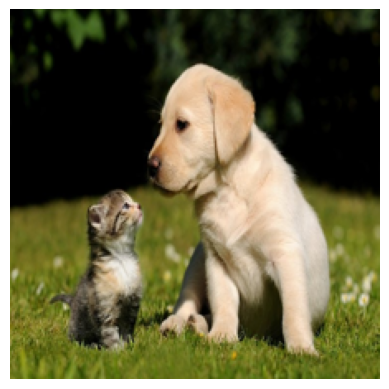

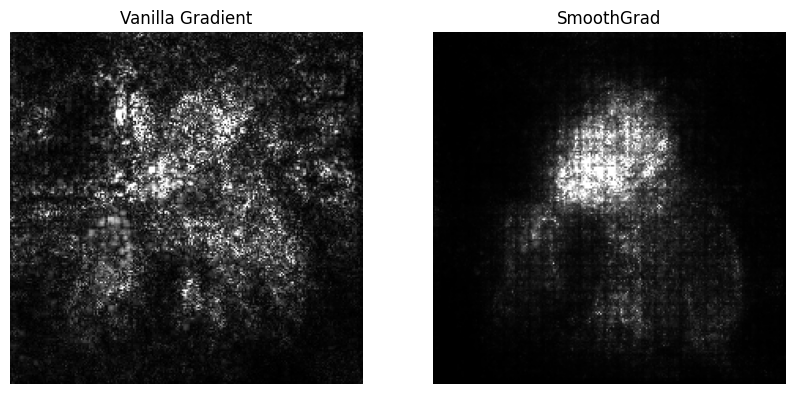

In [19]:
# Load the image
im_orig2 = LoadImage("https://drive.google.com/uc?export=view&id=1TuO4OoRutwpkwxr_T7W-imz5QvlIP20E")
imRes = PreprocessImageRes(im_orig2)

# Show the image
ShowImage(im_orig2)

predictions = model([np.array([imRes])])
prediction_class = np.argmax(predictions[0])
call_model_args = {class_idx_str: prediction_class}

print("Prediction class: " + str(prediction_class))


# Compute the vanilla mask and the smoothed mask.
vanilla_mask_3d_Res = gradient_saliency.GetMask(imRes, call_model_function, call_model_args)
smoothgrad_mask_3d_Res = gradient_saliency.GetSmoothedMask(imRes, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale_Res = saliency.VisualizeImageGrayscale(vanilla_mask_3d_Res)
smoothgrad_mask_grayscale_Res = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d_Res)

# Set up matplot lib figures.
ROWS = 1
COLS = 2
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale_Res, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale_Res, title='SmoothGrad', ax=P.subplot(ROWS, COLS, 2))

ResNet50 predicts class 208 which is "Labrador retriever".

### Let's plot the maps from the two different networks side by side

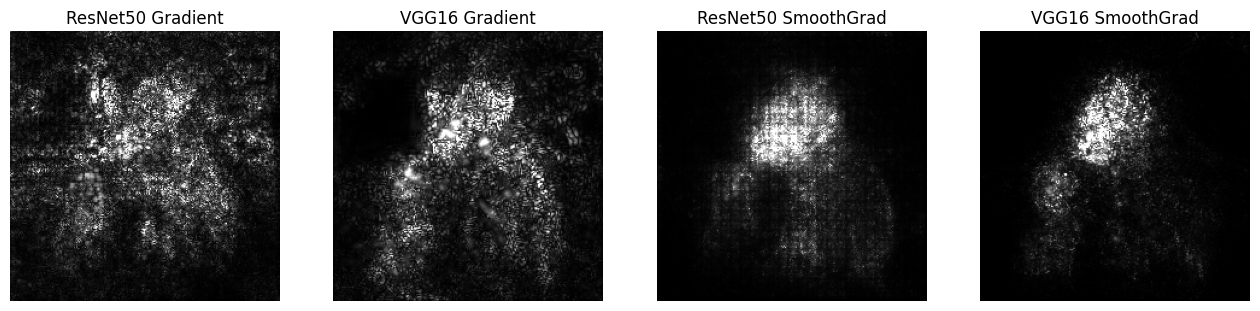

In [20]:
# Set up matplot lib figures.
ROWS = 1
COLS = 4
UPSCALE_FACTOR = 16
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale_Res, title='ResNet50 Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale_Res, title='ResNet50 SmoothGrad', ax=P.subplot(ROWS, COLS, 3))
ShowGrayscaleImage(vanilla_mask_grayscale, title='VGG16 Gradient', ax=P.subplot(ROWS, COLS, 2))
ShowGrayscaleImage(smoothgrad_mask_grayscale, title='VGG16 SmoothGrad', ax=P.subplot(ROWS, COLS, 4))

## Modifying Images

Now let's look at modifying the images. Can we get the model to misclassify? Can we cover part of the golden retriever puppy and get the model to classify the image as a cat (preferably as class 281, which is "tabby cat"). We have naively perturbed (by drawing on/covering parts) the image here in a few examples.

### Task:
Try modifying the image yourselves and see what happens!

Does the model behave in a way you would expect? Do the perturbations impact it's predictions in the same way it would a human's? Do the saliency maps help you understand what the model is doing?


Prediction class: 23


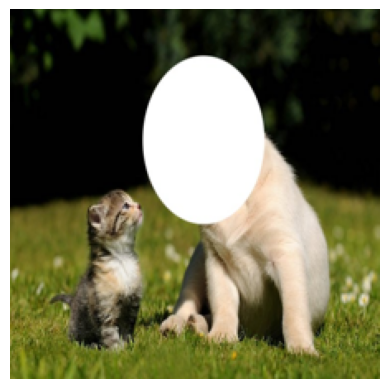

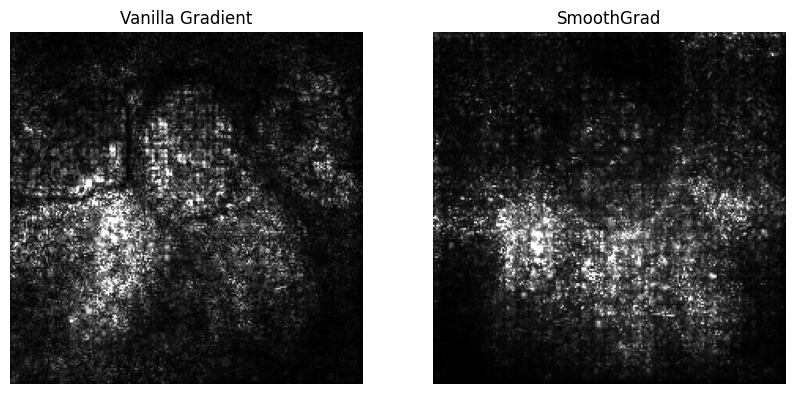

In [24]:
# Load the image
#Change the path in the line below if you want to try with a different image.
im_orig4 = LoadImage("https://drive.google.com/uc?export=view&id=11PoPYkzP-IO4u6FfiPTWISBybrgGTxtr")
im = PreprocessImage(im_orig4)

# Show the image
ShowImage(im_orig4)

predictions = model(np.array([im]))
prediction_class = np.argmax(predictions[0])
call_model_args = {class_idx_str: prediction_class}

print("Prediction class: " + str(prediction_class))

# Compute the vanilla mask and the smoothed mask.
vanilla_mask_3d_circle = gradient_saliency.GetMask(im, call_model_function, call_model_args)
smoothgrad_mask_3d_circle = gradient_saliency.GetSmoothedMask(im, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale_circle = saliency.VisualizeImageGrayscale(vanilla_mask_3d_circle)
smoothgrad_mask_grayscale_circle = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d_circle)

# Set up matplot lib figures.
ROWS = 1
COLS = 2
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale_circle, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale_circle, title='SmoothGrad', ax=P.subplot(ROWS, COLS, 2))

We have covered the dog's head, which in the smoothgrad map for the unperturbed image seemed to be the most important part of the input for the "Labrador retriever" class. Since we've perturbed the input, the network is now predicting class 23, which is "vulture" (which to a human is very different from a cat)! The maps are also now highlighting seemingly random parts of the image. As mentioned, since this is "random", different results are possible. Check: https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/ for your results.




Prediction class: 359


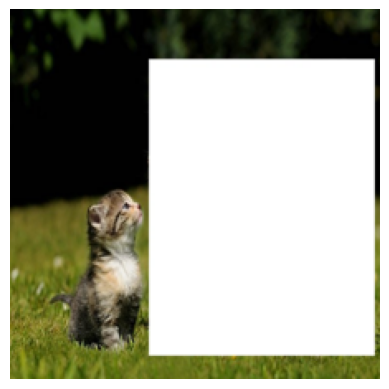

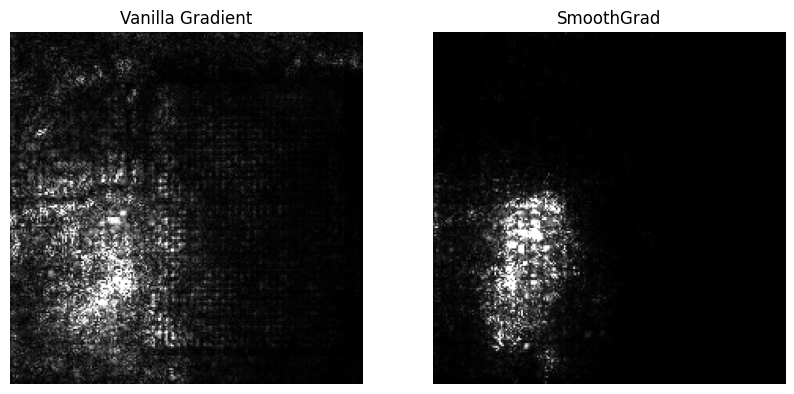

In [22]:
# Load the image
#Change the path in the line below if you want to try with a different image.
im_orig5 = LoadImage("https://drive.google.com/uc?export=view&id=1hw0kA7oQDkYlTosvEpfKt_FWGgw8XEh0")
im = PreprocessImage(im_orig5)

# Show the image
ShowImage(im_orig5)

predictions = model(np.array([im]))
prediction_class = np.argmax(predictions[0])
call_model_args = {class_idx_str: prediction_class}

print("Prediction class: " + str(prediction_class))

# Compute the vanilla mask and the smoothed mask.
vanilla_mask_3d_dots = gradient_saliency.GetMask(im, call_model_function, call_model_args)
smoothgrad_mask_3d_dots = gradient_saliency.GetSmoothedMask(im, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale_dots = saliency.VisualizeImageGrayscale(vanilla_mask_3d_dots)
smoothgrad_mask_grayscale_dots = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d_dots)

# Set up matplot lib figures.
ROWS = 1
COLS = 2
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale_dots, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale_dots, title='SmoothGrad', ax=P.subplot(ROWS, COLS, 2))

Next we've tried completely covering the dog part of the image. This time the saliency maps seem to focus mostly on the cat, however the model is predicting class 359 which is "ferret" - although somewhat closer to a cat than a vulture, still not what a human would classify from this image.

## Why doesn't covering the dog lead to the network classifying the cat?

Images that have been modified/perturb in this way are out of distribution for the network (the network won't have been trained on images with these kinds of perturbations/covers), so it's behaviour with these doesn't line up with how a human would interpret these images.

But do the saliency methods help realise this?

Prediction class: 282


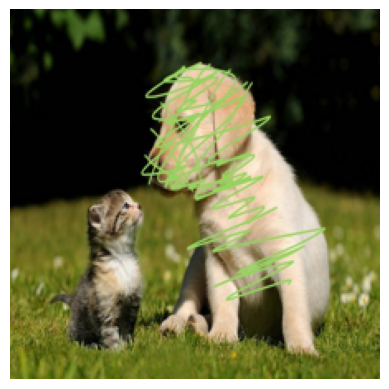

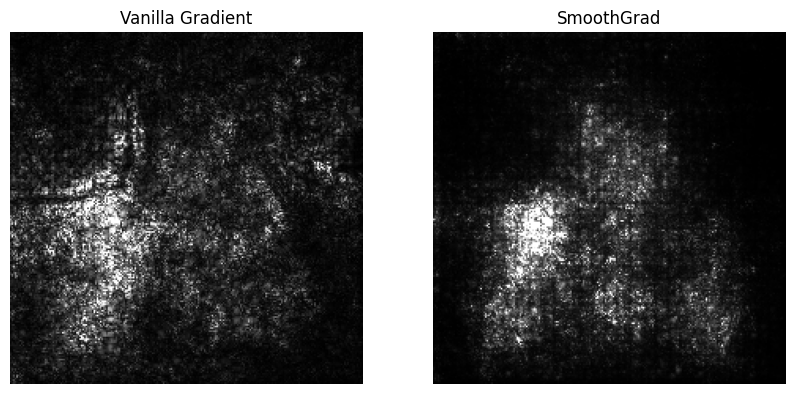

In [25]:
# Load the image
#Change the path in the line below if you want to try with a different image.
im_orig3 = LoadImage("https://drive.google.com/uc?export=view&id=13k3rfcStazAPr8NFgQM7K2ChgcT16-eC")
im = PreprocessImage(im_orig3)

# Show the image
ShowImage(im_orig3)

predictions = model(np.array([im]))
prediction_class = np.argmax(predictions[0])
call_model_args = {class_idx_str: prediction_class}

print("Prediction class: " + str(prediction_class))

# Compute the vanilla mask and the smoothed mask.
vanilla_mask_3d_scribble = gradient_saliency.GetMask(im, call_model_function, call_model_args)
smoothgrad_mask_3d_scribble = gradient_saliency.GetSmoothedMask(im, call_model_function, call_model_args)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale_scribble = saliency.VisualizeImageGrayscale(vanilla_mask_3d_scribble)
smoothgrad_mask_grayscale_scribble = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d_scribble)

# Set up matplot lib figures.
ROWS = 1
COLS = 2
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

# Render the saliency masks.
ShowGrayscaleImage(vanilla_mask_grayscale_scribble, title='Vanilla Gradient', ax=P.subplot(ROWS, COLS, 1))
ShowGrayscaleImage(smoothgrad_mask_grayscale_scribble, title='SmoothGrad', ax=P.subplot(ROWS, COLS, 2))

In one last attempt, we have perturbed the image by scribbling on the dog rather than covering it completely - the reasoning being that this is somewhat more similar to what might occur naturally (e.g. if the dog were partly obscured behind plants), however this is just be a lucky guess! This time the network predicts class 282, which is "tiger cat" (which is almost identical to tabby cat). The saliency maps now mostly focus on the cat but are still highlighting parts of the dog.

Note: Having also tried these images on VGG16, the same perturbations cause the model to predict completely different classes, and each model would likely behave differently with these kinds of out of distribution perturbations.



## Future resources

Check out the PAIR page: https://github.com/PAIR-code/saliency for more information. Some of the example notebooks also contain implementations of newer methods, e.g., https://github.com/PAIR-code/saliency/blob/master/Examples_pytorch.ipynb. On this page, you can also find links to the original papers which form the basis of their methods.

